In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/processed/disaster_prediction_dataset.xlsx")
df.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0009-TUR,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,TUR,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2019-08-05,2023-09-25


In [3]:
target = 'Disaster Type'

/var/folders/b6/77jq3l_n51s4g5kpd815pg140000gn/T/ipykernel_24629/3439439722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=target, order=df[target].value_counts().index, palette='viridis')


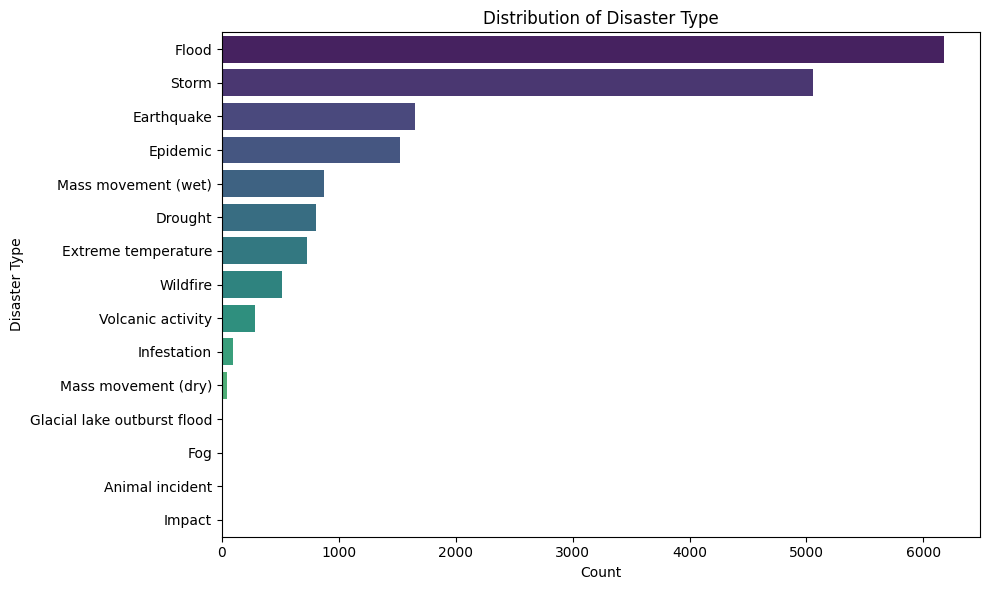

-- Missing Values in Top 10 Columns --
Reconstruction Costs, Adjusted ('000 US$)    99.774724
Reconstruction Costs ('000 US$)              99.769092
AID Contribution ('000 US$)                  95.635278
Insured Damage, Adjusted ('000 US$)          93.596531
Insured Damage ('000 US$)                    93.540212
River Basin                                  90.977698
No. Homeless                                 85.678081
Longitude                                    84.044830
Latitude                                     84.044830
Associated Types                             75.963055
dtype: float64


In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y=target, order=df[target].value_counts().index, palette='viridis')
plt.title('Distribution of Disaster Type')
plt.xlabel('Count')
plt.ylabel('Disaster Type')
plt.tight_layout()
plt.show()

print("-- Missing Values in Top 10 Columns --")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(10))

In [5]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17756 entries, 0 to 17755
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17756 non-null  object 
 1   Historic                                   17756 non-null  object 
 2   Classification Key                         17756 non-null  object 
 3   Disaster Group                             17756 non-null  object 
 4   Disaster Subgroup                          17756 non-null  object 
 5   Disaster Type                              17756 non-null  object 
 6   Disaster Subtype                           17756 non-null  object 
 7   External IDs                               4594 non-null   object 
 8   Event Name                                 4319 non-null   object 
 9   ISO                                        17756 non-null  object 
 10  Country               

(17756, 47)

In [6]:
duplicated_df = df.duplicated().sum()
duplicated_df

np.int64(0)

In [7]:
df.describe()

,AID Contribution ('000 US$),Magnitude,Latitude,Longitude,Start Year,Start Month,Start Day,End Year,End Month,End Day,...,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI
count,7.750000e+02,5.288000e+03,2833.000000,2833.000000,17756.000000,17384.000000,14155.000000,17756.000000,17091.000000,14265.000000,...,1.060200e+04,2.543000e+03,1.319300e+04,4.100000e+01,4.000000e+01,1.147000e+03,1.137000e+03,5.715000e+03,5.637000e+03,17348.000000
mean,2.005924e+04,3.666626e+04,18.720762,39.718250,1999.539536,6.458007,15.215472,1999.592814,6.613656,15.847950,...,8.301391e+05,7.159649e+04,6.817848e+05,5.595323e+06,7.100618e+06,1.001247e+06,1.380909e+06,8.445102e+05,1.361003e+06,56.548886
std,1.691388e+05,2.312792e+05,21.628624,77.333349,21.013058,3.383547,8.967713,21.002335,3.352265,8.902732,...,8.036395e+06,5.121321e+05,7.278962e+06,1.604484e+07,1.789556e+07,3.931998e+06,5.102017e+06,5.028629e+06,7.392502e+06,24.643844
min,1.000000e+00,-5.700000e+01,-72.640000,-178.252000,1900.000000,1.000000,1.000000,1900.000000,1.000000,1.000000,...,1.000000e+00,3.000000e+00,1.000000e+00,8.400000e+01,1.350000e+02,3.400000e+01,4.900000e+01,2.000000e+00,3.000000e+00,2.652223
25%,1.745000e+02,6.900000e+00,3.295000,-0.100000,1991.000000,4.000000,7.000000,1991.000000,4.000000,8.000000,...,1.300000e+03,5.000000e+02,7.000000e+02,6.500000e+04,1.021675e+05,5.450000e+04,9.982000e+04,1.000000e+04,2.058600e+04,41.652196
50%,7.210000e+02,1.440000e+02,23.200000,49.414000,2004.000000,7.000000,15.000000,2004.000000,7.000000,16.000000,...,1.000000e+04,3.000000e+03,6.000000e+03,5.380000e+05,5.534020e+05,1.860000e+05,2.875800e+05,7.000000e+04,1.385550e+05,58.643553
75%,3.648500e+03,5.180000e+03,36.739000,102.827000,2015.000000,9.000000,23.000000,2015.000000,9.000000,24.000000,...,9.307650e+04,1.649350e+04,6.000000e+04,5.200000e+06,5.548460e+06,5.850000e+05,8.834420e+05,3.750000e+05,6.908020e+05,75.468456
max,3.518530e+06,1.302587e+07,67.930000,179.650000,2026.000000,12.000000,31.000000,2026.000000,12.000000,31.000000,...,3.300000e+08,1.585000e+07,3.300000e+08,1.000000e+08,1.029495e+08,6.000000e+07,9.637551e+07,2.100000e+08,2.928555e+08,100.000000
